# Retrieval and ranking

A catalogue can contain thousands of films. We could ask a large model to score every film for every user, but that wastes work. Instead, a recommender works in two steps: **retrieve** a small set of plausible films, then **rank** that set carefully.

We already know both kinds of evidence from earlier chapters. Chapter 2 used genres and a user's taste; chapter 3 used ratings from similar users and films. Now we will put those recommenders to work together on MovieLens.

```text
1,682 films -> retrieve candidates -> rank candidates -> show 10 films
                 content + crowd        learned order
```

We will train a small ranking model and evaluate it on later ratings. Those are different questions, so they get different plots: one for training loss, another for recommendation quality. A falling training loss alone does not prove that recommendations got better.

## 1. Two questions, not one

A recommender first asks, **“Which films might fit?”** This is retrieval. It should be quick and generous: missing a good film here means the next step can never show it.

Then it asks, **“Of these candidates, which should come first?”** This is ranking. It can combine several signals and spend more work on a much smaller list.

We will retrieve from the same genre and rating evidence used in chapters 2 and 3. Then we will train a small ranker to combine those signals. The training curve and the held-out recommendation results will be plotted separately.

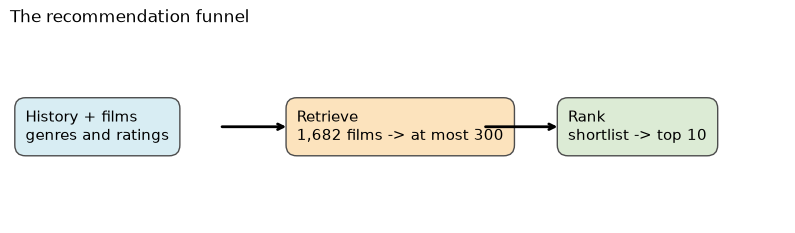

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")
boxes = [
    (0.02, "History + films", "genres and ratings", "#d8edf3"),
    (0.37, "Retrieve", "1,682 films -> at most 300", "#fce3bd"),
    (0.72, "Rank", "shortlist -> top 10", "#dcebd5"),
]
for x, title, detail, color in boxes:
    ax.text(
        x, 0.5, f"{title}\n{detail}", transform=ax.transAxes,
        ha="left", va="center", fontsize=11,
        bbox={"boxstyle": "round,pad=0.7", "facecolor": color, "edgecolor": "0.3"},
    )
for start, end in ((0.27, 0.36), (0.61, 0.71)):
    ax.annotate("", xy=(end, 0.5), xytext=(start, 0.5), xycoords="axes fraction",
                arrowprops={"arrowstyle": "->", "lw": 2})
ax.set_title("The recommendation funnel", loc="left")
plt.show()

## 2. Reuse the same films and ratings

Chapter 2 described films with genres; chapter 3 learned from the people who rated them. We will use both signals on **MovieLens 100K**. A row contains user, film, stars, and time.

We split by time: the first 70% builds retrieval scores, the next 15% trains the ranker, and the last 15% tests it. A rating of 4 or 5 is a positive example; a rating of 1 or 2 is a negative example. We leave rating 3 out of ranker training because it is ambiguous.

In [38]:
import csv
import urllib.request
import zipfile
from pathlib import Path

DATASET_DIR = Path(".cache/ml-100k")
archive_path = DATASET_DIR.parent / "ml-100k.zip"
if not (DATASET_DIR / "u.data").exists():
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip", archive_path
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(DATASET_DIR.parent)

print("MovieLens ready:", DATASET_DIR)

MovieLens ready: .cache/ml-100k


In [39]:
ratings = np.loadtxt(DATASET_DIR / "u.data", delimiter="\t", dtype=np.int64)
ratings = ratings[np.argsort(ratings[:, 3], kind="stable")]

with (DATASET_DIR / "u.genre").open(encoding="latin-1") as file:
    GENRE_NAMES = tuple(line.split("|", 1)[0] for line in file if line.strip())
with (DATASET_DIR / "u.item").open(encoding="latin-1", newline="") as file:
    item_rows = {int(row[0]): (row[1], row[5:24]) for row in csv.reader(file, delimiter="|")}

ITEM_IDS = np.array(sorted(item_rows))
USER_IDS = np.unique(ratings[:, 0])
ITEM_INDEX = {int(item_id): row for row, item_id in enumerate(ITEM_IDS)}
USER_INDEX = {int(user_id): row for row, user_id in enumerate(USER_IDS)}
ITEM_TITLES = [item_rows[int(item_id)][0] for item_id in ITEM_IDS]
GENRES = np.array([item_rows[int(item_id)][1] for item_id in ITEM_IDS], dtype=float)

events = np.column_stack((
    [USER_INDEX[int(user)] for user in ratings[:, 0]],
    [ITEM_INDEX[int(item)] for item in ratings[:, 1]],
    ratings[:, 2:4],
))
print(f"{len(USER_IDS):,} users | {len(ITEM_IDS):,} films | {len(ratings):,} ratings")

943 users | 1,682 films | 100,000 ratings


### a. Keep the future hidden

All ratings are sorted by timestamp before splitting. The early window builds user histories; the middle window supplies examples for learning the ranker; the final window answers the test question. The test ratings are never used to build candidates or fit model weights.

In [40]:
train_end = int(0.70 * len(events))
valid_end = int(0.85 * len(events))
train_events = events[:train_end]
valid_events = events[train_end:valid_end]
test_events = events[valid_end:]

print(f"History: {len(train_events):,} ratings")
print(f"Ranker training labels: {len(valid_events):,} ratings")
print(f"Final test: {len(test_events):,} ratings")

History: 70,000 ratings
Ranker training labels: 15,000 ratings
Final test: 15,000 ratings


## 3. Retrieve candidates from familiar signals

For one user, each chapter suggests a different doorway into the catalogue:

- **Content** (chapter 2): films with genres like the films this user liked.
- **Collaborative** (chapter 3): films liked by people who liked similar films.
- **Popularity**: a dependable fallback when personal history is thin.

Each source returns its own top 100 unseen films. We merge and deduplicate them. The ranker will receive no more than 300 candidates instead of all 1,682 films.

In [41]:
def make_history(events):
    seen = np.zeros((len(USER_IDS), len(ITEM_IDS)), dtype=bool)
    liked = np.zeros(seen.shape, dtype=np.float32)
    users, items = events[:, 0], events[:, 1]
    seen[users, items] = True
    positive = events[:, 2] >= 4
    liked[users[positive], items[positive]] = 1.0
    return seen, liked


train_seen, train_liked = make_history(train_events)
print(f"Known ratings: {train_seen.sum():,}; positive ratings: {train_liked.sum():,.0f}")

Known ratings: 70,000; positive ratings: 38,968


A zero in `seen` means the user has not rated that film; a one in `liked` means the rating was at least 4. This is the same distinction between unknown and positive feedback used in chapter 3.

The content score compares genre profiles. The collaborative score averages item-to-item similarity around the user's liked films. Popularity counts how many users liked each film.

In [42]:
def build_retrieval_scores(seen, liked):
    profiles = liked @ GENRES
    genre_norm = np.linalg.norm(GENRES, axis=1)
    profile_norm = np.linalg.norm(profiles, axis=1)
    denom = profile_norm[:, None] * genre_norm[None, :]
    content = np.divide(profiles @ GENRES.T, denom, out=np.zeros_like(denom), where=denom > 0)

    co_likes = liked.T @ liked
    item_norm = np.sqrt(liked.sum(axis=0))
    denom = np.outer(item_norm, item_norm)
    similarity = np.divide(co_likes, denom, out=np.zeros_like(co_likes), where=denom > 0)
    np.fill_diagonal(similarity, 0)
    collaborative = liked @ similarity / np.maximum(liked.sum(axis=1, keepdims=True), 1)

    popularity = np.log1p(liked.sum(axis=0))
    popularity /= max(popularity.max(), 1)
    return {"seen": seen, "content": content, "collaborative": collaborative, "popularity": popularity}


train_scores = build_retrieval_scores(train_seen, train_liked)
print("Content scores:", train_scores["content"].shape)
print("Collaborative scores:", train_scores["collaborative"].shape)

Content scores: (943, 1682)
Collaborative scores: (943, 1682)


### a. Merge the shortlists

The retriever asks each source for its best unseen films, then takes their union. A film found by two sources appears only once, but we keep three yes/no flags so the ranker can tell where it came from.

In [43]:
RETRIEVAL_K = 100


def retrieve(user_row, snapshot, k=RETRIEVAL_K):
    eligible = np.flatnonzero(~snapshot["seen"][user_row])
    scores = {name: snapshot[name][user_row] if name != "popularity" else snapshot[name]
              for name in ("content", "collaborative", "popularity")}
    pools = {
        name: set(eligible[np.argsort(-values[eligible], kind="stable")[:k]])
        for name, values in scores.items()
    }
    candidates = np.array(sorted(set().union(*pools.values())), dtype=int)
    columns = [scores[name][candidates] for name in scores]
    columns += [np.array([item in pools[name] for item in candidates], dtype=float)
                for name in pools]
    return candidates, np.column_stack(columns), pools

For a first look, we will rank the union by the sum of its three raw scores. This is only a temporary baseline. The next stage learns how much each signal should count.

In [44]:
sample_user_row = USER_INDEX[1]
sample_items, sample_features, sample_pools = retrieve(sample_user_row, train_scores)
print(f"User 1: {len(sample_items)} unique candidates")
print("Candidates found by each source:", {name: len(pool) for name, pool in sample_pools.items()})

simple_scores = sample_features[:, :3].sum(axis=1)
for position in np.argsort(-simple_scores)[:8]:
    item_row = sample_items[position]
    print(f"{ITEM_TITLES[item_row]} | content={sample_features[position, 0]:.2f} "
          f"similar-users={sample_features[position, 1]:.2f} "
          f"popular={sample_features[position, 2]:.2f}")

User 1: 222 unique candidates
Candidates found by each source: {'content': 100, 'collaborative': 100, 'popularity': 100}
One Flew Over the Cuckoo's Nest (1975) | content=0.66 similar-users=0.30 popular=0.86
Stand by Me (1986) | content=0.70 similar-users=0.28 popular=0.79
To Kill a Mockingbird (1962) | content=0.66 similar-users=0.27 popular=0.83
Schindler's List (1993) | content=0.56 similar-users=0.30 popular=0.88
Casablanca (1942) | content=0.60 similar-users=0.30 popular=0.85
It's a Wonderful Life (1946) | content=0.66 similar-users=0.27 popular=0.82
Trainspotting (1996) | content=0.66 similar-users=0.23 popular=0.85
Cool Hand Luke (1967) | content=0.75 similar-users=0.21 popular=0.76


## 4. Train the ranker on judgments

The ranker sees only the retrieved shortlist. For each candidate, it gets six small clues: three scores and three flags saying which retriever found it.

The middle time window supplies labels. A later rating of 4 or 5 means “liked”; 1 or 2 means “not liked.” We use only rated candidates for training: an unobserved film is **unknown**, not a reliable negative. If retrieval missed a future favorite, no ranker can learn to rescue it.

In [45]:
validation_by_user = {}
for user, item, rating, _ in valid_events:
    if rating != 3:
        validation_by_user.setdefault(user, []).append((item, rating))

ranker_rows, ranker_labels = [], []
retrieved_validation_likes = 0
for user, judgments in validation_by_user.items():
    candidates, features, _ = retrieve(user, train_scores)
    position = {int(item): row for row, item in enumerate(candidates)}
    for item, rating in judgments:
        if int(item) in position:
            ranker_rows.append(features[position[int(item)]])
            ranker_labels.append(float(rating >= 4))
            retrieved_validation_likes += int(rating >= 4)

X_train = np.asarray(ranker_rows)
y_train = np.asarray(ranker_labels)
print(f"Ranker examples: {len(y_train):,} | liked: {int(y_train.sum()):,}")
print(f"Future likes available to train: {retrieved_validation_likes:,}")

Ranker examples: 4,199 | liked: 3,524
Future likes available to train: 3,524


The ranker learns an order, not a star rating. For the same user, it sees a later-liked candidate and a low-rated candidate, then learns to give the liked film a higher score:

$$
P(i \text{ above } j) = \sigma\!\left(w^\mathsf{T}(x_i - x_j)\right)
$$

Here $x_i$ and $x_j$ are the six clues for two films, $w$ is learned from the validation window, and $\sigma$ turns the score difference into a probability. This pairwise objective matches the job of a ranker: put the better candidate first.

In [46]:
preference_pairs = []
for user, judgments in validation_by_user.items():
    candidates, features, _ = retrieve(user, train_scores)
    positions = {int(item): row for row, item in enumerate(candidates)}
    liked_rows, low_rows = [], []
    for item, rating in judgments:
        if int(item) in positions:
            row = positions[int(item)]
            if rating >= 4:
                liked_rows.append(row)
            elif rating <= 2:
                low_rows.append(row)
    preference_pairs.extend(features[liked] - features[low] for liked in liked_rows for low in low_rows)

X_pairs = np.asarray(preference_pairs)
print(f"Within-user liked-vs-low-rated pairs: {len(X_pairs):,}")

Within-user liked-vs-low-rated pairs: 20,557


In [47]:
feature_mean = X_train.mean(axis=0)
feature_scale = X_train.std(axis=0)
feature_scale[feature_scale == 0] = 1.0
X_pairs_scaled = X_pairs / feature_scale
ranker_weights = np.zeros(X_pairs_scaled.shape[1])
training_loss = []

for epoch in range(301):
    margin = X_pairs_scaled @ ranker_weights
    wrong_order = 1 / (1 + np.exp(np.clip(margin, -30, 30)))
    training_loss.append(np.mean(np.logaddexp(0, -margin)))
    gradient = -(X_pairs_scaled.T @ wrong_order) / len(X_pairs_scaled)
    ranker_weights -= 0.1 * (gradient + 0.01 * ranker_weights)

ranker_bias = 0.0
print(f"Pairwise loss: {training_loss[0]:.3f} -> {training_loss[-1]:.3f}")
print("Learned feature weights:", np.round(ranker_weights, 2))

Pairwise loss: 0.693 -> 0.612
Learned feature weights: [ 0.12  0.14  0.48 -0.18  0.01  0.  ]


### b. What this graph answers

This is the **training** graph: it shows whether the ranker is fitting the validation-window labels. It says nothing by itself about whether later recommendations are good. We will keep that question for the final test window.

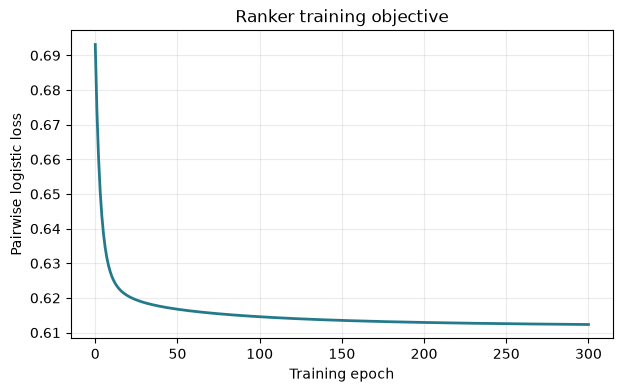

In [48]:
plt.figure(figsize=(7, 4))
plt.plot(training_loss, color="#247a8b", linewidth=2)
plt.xlabel("Training epoch")
plt.ylabel("Pairwise logistic loss")
plt.title("Ranker training objective")
plt.grid(alpha=0.25)
plt.show()

## 5. Measure recommendation quality on later ratings

Now we move the clock forward. The ranker's inputs are built from the first 85% of ratings; only the final 15% is used as the test. A future rating of 4 or 5 is relevant.

We will answer two separate questions:

1. **Candidate recall:** did the union retrieve the films the user later liked?
2. **Ranking quality:** of the retrieved films, did the ranker place future likes near the top?

Recall@10 measures how many of a user's future likes appear in the first ten. NDCG@10 also rewards putting those likes earlier. The ranker cannot recover a film that retrieval missed.

In [49]:
known_events = np.vstack((train_events, valid_events))
test_seen, test_liked = make_history(known_events)
test_scores = build_retrieval_scores(test_seen, test_liked)

future_likes = {}
for user, item, rating, _ in test_events:
    if rating >= 4:
        future_likes.setdefault(user, set()).add(int(item))
test_users = sorted(future_likes)
print(f"Users with at least one future like: {len(test_users):,}")

Users with at least one future like: 212


In [50]:
def recall_at_k(ranked, relevant, k=10):
    return len(set(ranked[:k]) & relevant) / len(relevant)


def ndcg_at_k(ranked, relevant, k=10):
    dcg = sum(1 / np.log2(position + 2) for position, item in enumerate(ranked[:k])
              if item in relevant)
    ideal = sum(1 / np.log2(position + 2) for position in range(min(k, len(relevant))))
    return dcg / ideal

In [51]:
ranking_metrics = {name: {"recall": [], "ndcg": []} for name in ("Simple fusion", "Learned ranker")}
candidate_recall = []

for user in test_users:
    candidates, features, _ = retrieve(user, test_scores)
    relevant = future_likes[user]
    candidate_recall.append(len(set(candidates) & relevant) / len(relevant))

    fusion_order = candidates[np.argsort(-features[:, :3].sum(axis=1), kind="stable")]
    scaled = (features - feature_mean) / feature_scale
    ranker_order = candidates[np.argsort(-(scaled @ ranker_weights + ranker_bias), kind="stable")]
    for name, order in (("Simple fusion", fusion_order), ("Learned ranker", ranker_order)):
        ranking_metrics[name]["recall"].append(recall_at_k(order, relevant))
        ranking_metrics[name]["ndcg"].append(ndcg_at_k(order, relevant))

mean_candidate_recall = float(np.mean(candidate_recall))
print(f"Mean candidate recall (union of up to 300): {mean_candidate_recall:.3f}")
for name, metrics in ranking_metrics.items():
    print(f"{name}: Recall@10={np.mean(metrics['recall']):.3f}, "
          f"NDCG@10={np.mean(metrics['ndcg']):.3f}")

Mean candidate recall (union of up to 300): 0.475
Simple fusion: Recall@10=0.083, NDCG@10=0.271
Learned ranker: Recall@10=0.070, NDCG@10=0.241


### a. Is retrieval finding enough?

At `K=100`, each source can return 100 films, so the ranker sees at most 300 unique candidates. Candidate recall is an upper limit: the ranker cannot recommend a future favorite that is absent from the union.

The next graph changes the retrieval budget. Its x-axis is the average number of candidates passed onward; its y-axis is the share of future likes that retrieval found.

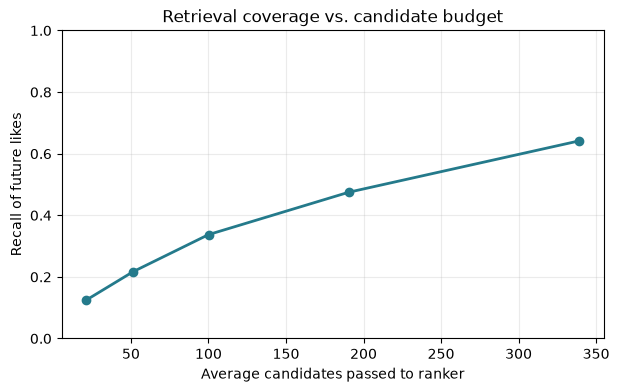

In [52]:
retrieval_budgets = [10, 25, 50, 100, 200]
mean_sizes, mean_coverages = [], []
for budget in retrieval_budgets:
    sizes, coverage = [], []
    for user in test_users:
        candidates, _, _ = retrieve(user, test_scores, k=budget)
        sizes.append(len(candidates))
        coverage.append(len(set(candidates) & future_likes[user]) / len(future_likes[user]))
    mean_sizes.append(np.mean(sizes))
    mean_coverages.append(np.mean(coverage))

plt.figure(figsize=(7, 4))
plt.plot(mean_sizes, mean_coverages, marker="o", color="#247a8b", linewidth=2)
plt.xlabel("Average candidates passed to ranker")
plt.ylabel("Recall of future likes")
plt.title("Retrieval coverage vs. candidate budget")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.show()

### b. Rank order on the untouched test window

This chart is **not** the training curve. It shows recommendation quality on later ratings, comparing the learned order with the simple score sum. Candidate recall is the ceiling: here, retrieval found about 48% of future likes, so ranking cannot exceed that without improving retrieval.

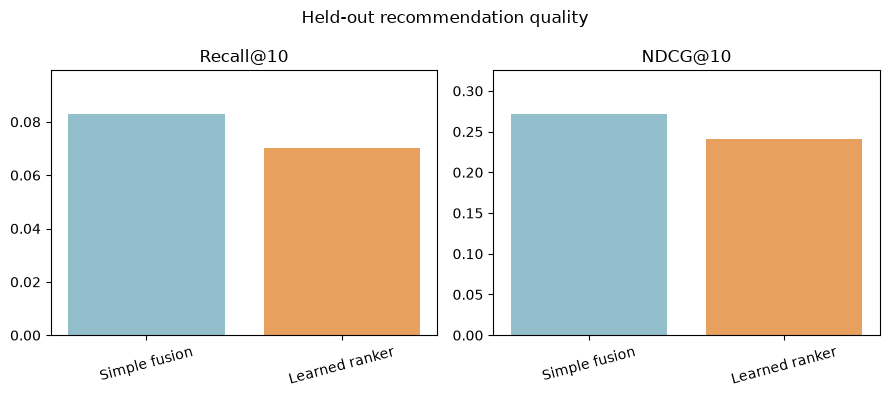

In [53]:
names = list(ranking_metrics)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, metric, title in zip(axes, ("recall", "ndcg"), ("Recall@10", "NDCG@10")):
    values = [np.mean(ranking_metrics[name][metric]) for name in names]
    axis.bar(names, values, color=("#93bfcc", "#e7a05d"))
    axis.set_title(title)
    axis.set_ylim(0, max(values) * 1.2)
    axis.tick_params(axis="x", rotation=15)
fig.suptitle("Held-out recommendation quality")
fig.tight_layout()
plt.show()

### c. The ranker can only reorder

Here is the same user's candidate set under two orderings. Notice what changes, and what does not: both lists contain films from the same retrieved union.

In [54]:
demo_items, demo_features, _ = retrieve(sample_user_row, test_scores)
simple_order = np.argsort(-demo_features[:, :3].sum(axis=1), kind="stable")
learned_scores = ((demo_features - feature_mean) / feature_scale) @ ranker_weights
learned_order = np.argsort(-learned_scores, kind="stable")

for title, order in (("Simple fusion", simple_order), ("Learned ranker", learned_order)):
    print(f"{title}:")
    for position in order[:5]:
        print("  " + ITEM_TITLES[demo_items[position]])

Simple fusion:
  One Flew Over the Cuckoo's Nest (1975)
  Stand by Me (1986)
  Titanic (1997)
  To Kill a Mockingbird (1962)
  Cool Hand Luke (1967)
Learned ranker:
  Schindler's List (1993)
  One Flew Over the Cuckoo's Nest (1975)
  English Patient, The (1996)
  Casablanca (1942)
  To Kill a Mockingbird (1962)


### What did we learn from the numbers?

The training loss fell from `0.693` to `0.612`, but the learned ranker did **not** beat simple fusion on the final test: Recall@10 was `0.070` versus `0.083`, and NDCG@10 was `0.241` versus `0.271`. Lower training loss is not proof of better recommendations. The candidate union found only `0.475` of future likes on average, so a large share was already out of reach before ranking began.

This is a useful result, not a reason to hide the chart. It tells us where to investigate: improve candidate sources, inspect which users and films are missed, and tune ranking features using a validation split. Do not tune against the final test set.

These are offline ratings, not clicks. MovieLens does not say which films were shown, so an unobserved film is not a trustworthy negative. A real system should log impressions, compare rankers in a randomized A/B test, and monitor user outcomes and guardrails.

### Try it yourself

1. Change `RETRIEVAL_K` or the budgets in the coverage graph. How many more candidates does each extra point of recall cost?
2. Add a two-tower candidate source from chapter 4. Does it find future likes missed by content, collaborative, and popularity retrieval?
3. Add another ranker feature, train it on the middle window, and compare both test metrics. Keep the final test untouched until the end.

### In summary

- **Retrieval** gathers a broad shortlist from several sources; **ranking** orders that shortlist using richer evidence.
- A ranker cannot recommend an item that retrieval missed. Measure candidate recall before blaming the ranking model.
- Training loss measures fit to training examples. Recall@10 and NDCG@10 measure held-out recommendation order; these curves answer different questions.
- More features or a more complex model do not guarantee better test results. Compare with a simple baseline.
- Use chronological evaluation, treat unobserved items as unknown, and use A/B tests to measure real user outcomes.